In [1]:
import joblib

In [2]:
model = joblib.load(f"../models/random_forest_regressor.joblib")

In [3]:
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

c:\Users\stasn\OneDrive\Desktop\Shadmanee\MSc\CSE713\AQI_prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

In [12]:
df = pd.read_csv("../main datasets/feature_engineered_dataset.csv")

In [13]:
import joblib
le = joblib.load("../encoder/city_encoder.joblib")

In [14]:
df["city_encoded"] = le.transform(df["city"])

In [15]:
df = df.sample(1000)

In [16]:
X_test = df.drop(columns=["us_aqi", "date", "city"])
y_test = df["us_aqi"]

Displaying SHAP Summary Plot:


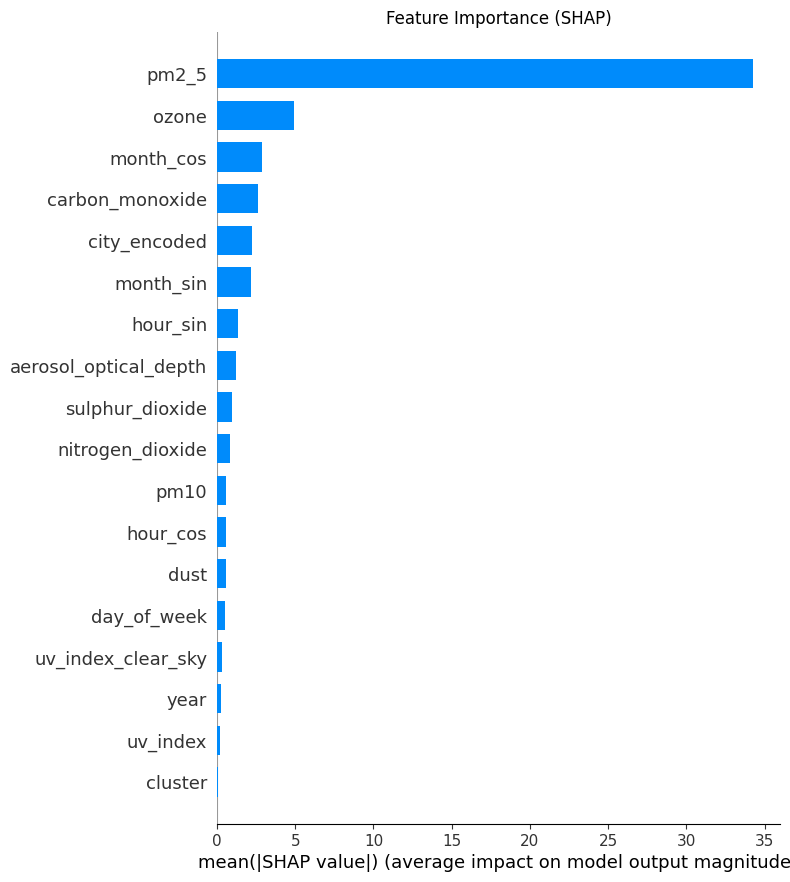


Displaying SHAP Beeswarm Plot:


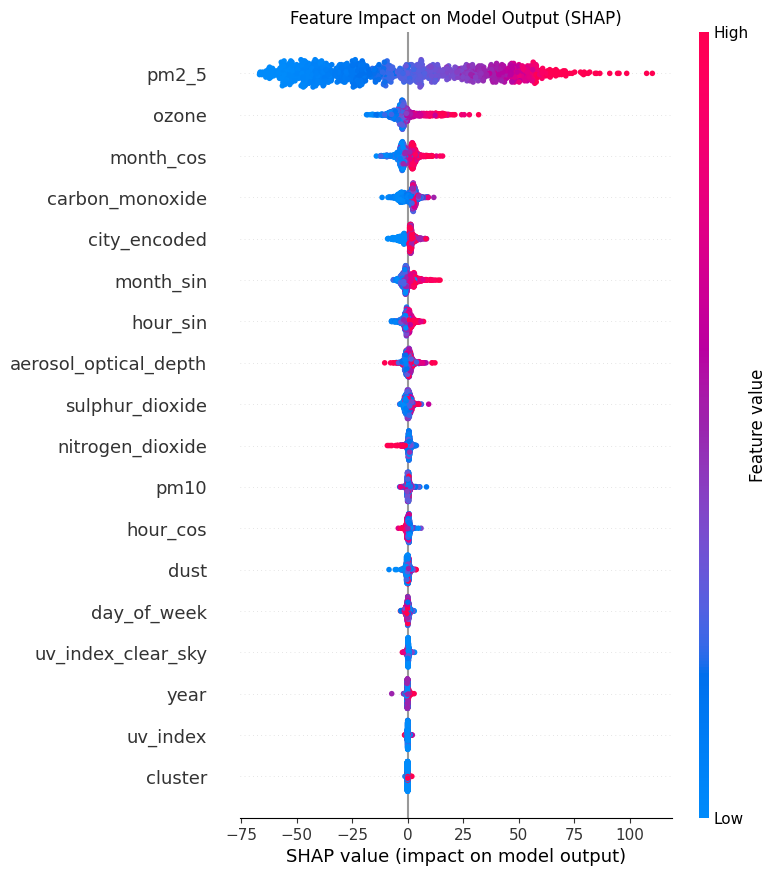

In [18]:
# Create the SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Create the summary plot
print("Displaying SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP)")
plt.show()

# A more detailed beeswarm plot
print("\nDisplaying SHAP Beeswarm Plot:")
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Impact on Model Output (SHAP)")
plt.show()